# Adaptive Ensemble Forecasting with Concentration Penalties
## Full Analysis Report

This notebook is a self-contained walkthrough of all analysis in this repository. It covers:

1. **The problem** — why static forecast combination fails under regime change
2. **The simulation environment** — a three-regime macro model with stochastic volatility
3. **The forecaster panel** — 18 heterogeneous linear and heuristic models
4. **All ensemble methods** — from equal-weight mean to multiplicative-weight RL bandits
5. **The concentration penalty** — theoretical motivation and the λ_t schedule
6. **Simulation results** — across horizons h = 1 through h = 24, two loss functions
7. **Monte Carlo win rates** — 500-simulation head-to-head comparisons
8. **Real-data validation** — Survey of Professional Forecasters (SPF) and M3 macro competition data
9. **Key lessons** — what works, what doesn't, and why

In [1]:
import sys
import math
import warnings
from pathlib import Path
import importlib

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from matplotlib.colors import TwoSlopeNorm
import matplotlib.gridspec as gridspec

warnings.filterwarnings('ignore')

PROJECT_ROOT = Path.cwd().resolve().parent if Path.cwd().name == 'analyses' else Path.cwd().resolve()
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

import src.data.simulator as simulator
import src.ensemblers.ensemblers as ensemblers
from src.ensemblers.rl import KappaBandit, RuleSelectionBandit
from src.evaluation import dual_loss_with_rl as runner
from src.evaluation import optuna_tuning as ot

simulator = importlib.reload(simulator)
ensemblers = importlib.reload(ensemblers)

RESULTS = PROJECT_ROOT / 'analyses' / 'results'
plt.rcParams.update({'figure.dpi': 120, 'axes.grid': True, 'grid.alpha': 0.25,
                     'axes.spines.top': False, 'axes.spines.right': False})

print(f'Project root: {PROJECT_ROOT}')
print(f'Results dir:  {RESULTS}')

Project root: /home/clayt/Ensemble-Forecasting
Results dir:  /home/clayt/Ensemble-Forecasting/analyses/results


---
## 1. The Problem: Why Forecast Combination is Hard

When multiple forecasters are available (different models, different institutions, different vintage assumptions), combining them into a single forecast is appealing for two reasons:

- **Diversification** — no single model dominates in all regimes
- **Robustness** — errors that are idiosyncratic to one model average out

The naive approach is the **equal-weight mean**. It is famously hard to beat in practice (*"forecast combination puzzle"*). But the mean has a fatal flaw: it ignores the heterogeneity of forecast quality, and it never adapts as the relative quality of models shifts.

This project investigates **online adaptive ensembling** — methods that update forecast weights each period using only the information available up to that point — augmented with a **concentration penalty** designed to prevent the weight vector from collapsing onto a single expert when uncertainty is high.

### The core idea

Let $\hat{y}_{i,t}$ be forecaster $i$'s prediction of $y_t$, and let $w_{i,t} \geq 0$, $\sum_i w_{i,t} = 1$ be the ensemble weights. The combined forecast is $\hat{y}^c_t = \sum_i w_{i,t} \hat{y}_{i,t}$.

Online methods update weights after observing the outcome:
$$w_{t+1} = \text{update}(w_t,\, \nabla \ell_t(w_t),\, s_t)$$

where $\ell_t$ is the loss at time $t$ and $s_t$ is a **state variable** measuring current macroeconomic uncertainty (here, normalised stochastic volatility of inflation).

The penalty we study forces weights toward uniform when $s_t$ is high:
$$\lambda_t = \lambda_{\min} + \kappa \cdot \log(1 + \tilde{s}_t)$$

where $\tilde{s}_t$ is an exponential moving average of $s_t$ and $\kappa$ is a tunable sensitivity parameter. This is the **Brainard (1967) attenuation principle** operationalised as a regularisation term.

---
## 2. The Simulation Environment

Since real macro data is limited (short samples, single history), we use a calibrated simulation to evaluate methods across many independent draws. The environment is a three-regime New-Keynesian reduced form:

### Regimes
| Regime | Description | Key feature |
|--------|-------------|-------------|
| 0 | Anchored / normal | Low persistence, Phillips curve active |
| 1 | Unanchored / high persistence | $\alpha \approx 0.97$, broken policy transmission |
| 2 | Supply-shock / pass-through | Strong cost-push channel $\gamma \approx 0.95$ |

Regimes switch according to a Markov chain. In the **discriminating** scenario used throughout this analysis, switching is relatively frequent and structural differences are sharp, making it genuinely hard to track the right model.

### Equations
- **Inflation:** $\pi_t = \alpha_{s_t}\pi_{t-1} + \beta_{s_t} x_{t-1} + \gamma_{s_t} u_t + \varepsilon_t^\pi$
- **Output gap:** $x_t = \rho_{s_t} x_{t-1} - \phi_{s_t}(i_{t-1} - \pi_{t-1}) + \varepsilon_t^x$
- **Policy rule:** $i_t = \psi_\pi^{(s_t)} \pi_t + \psi_x^{(s_t)} x_t + \varepsilon_t^i$
- **Supply shock:** $u_t = \rho_u u_{t-1} + \sigma_u \varepsilon_t^u$
- **Stochastic volatility:** $\log \sigma_t^2 = \mu_{s_t} + \phi_{SV}(\log \sigma_{t-1}^2 - \mu_{s_{t-1}}) + \tau \varepsilon_t^{SV}$

The state uncertainty variable exposed to ensemblers is $\sigma_t^\pi$ (normalised to mean 1). Crucially, the **latent regime $s_t$ is never observed** — only $\sigma_t^\pi$ is available as a signal.

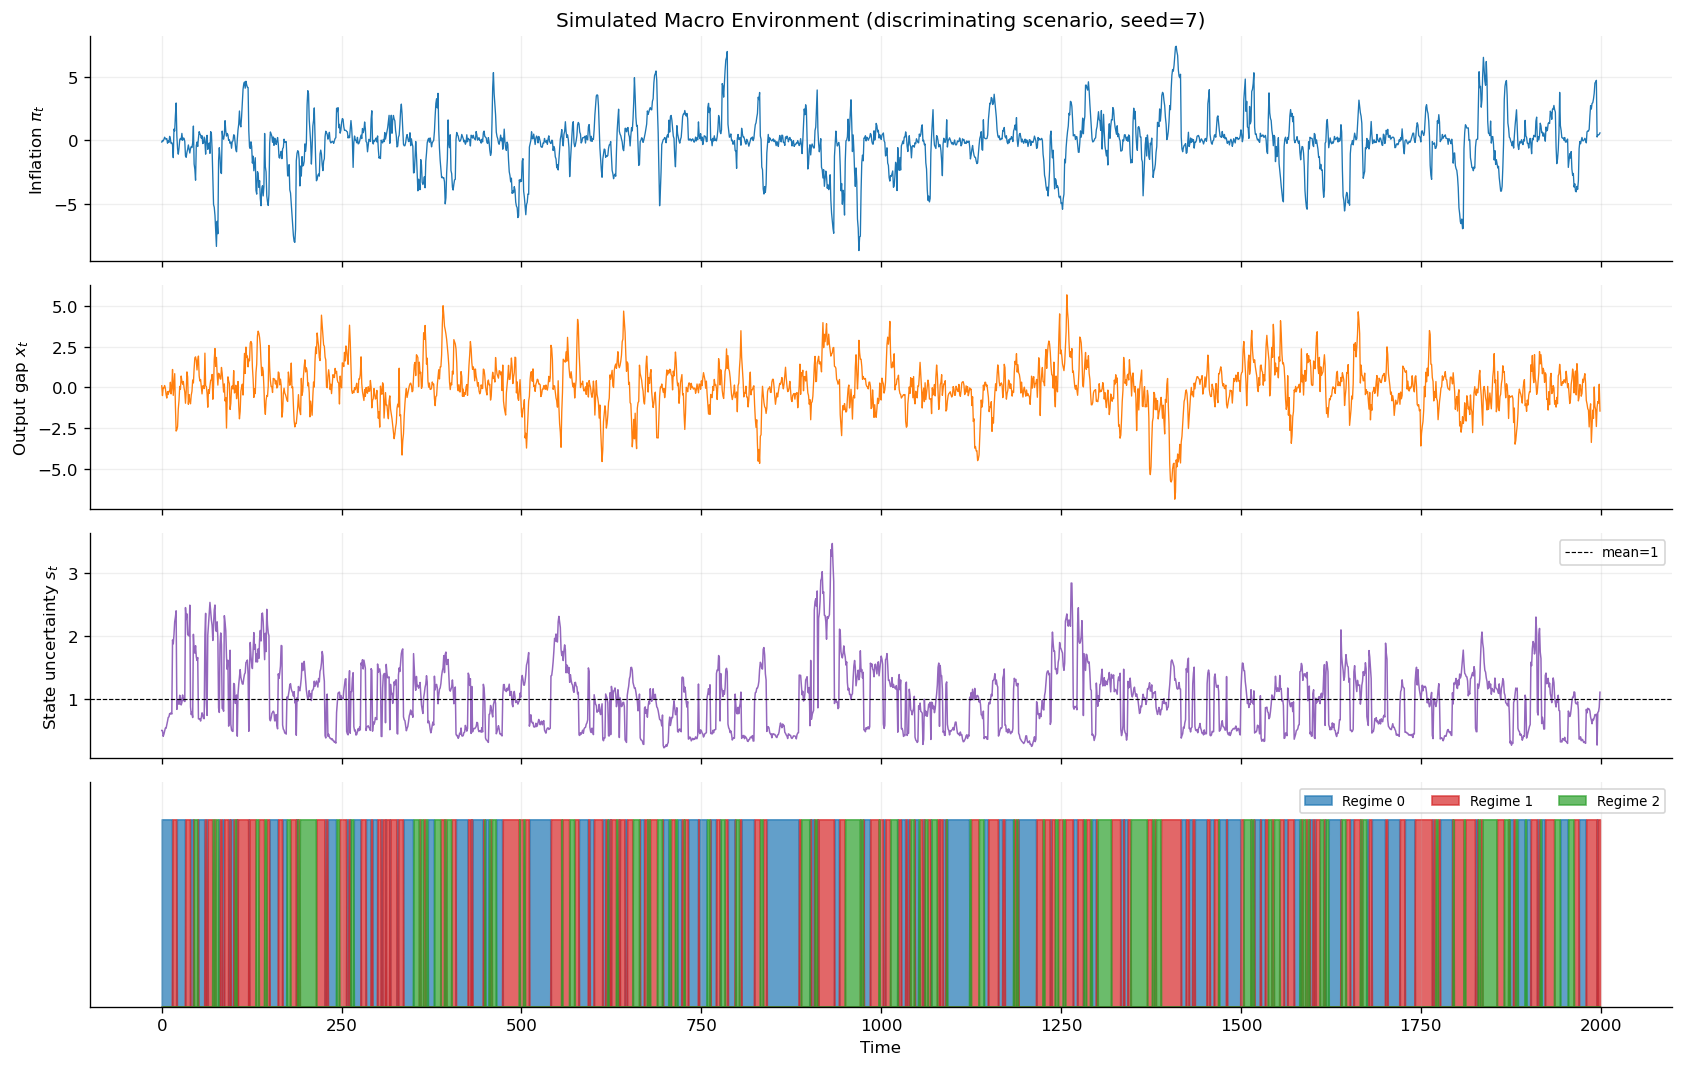

Regime shares: 0: 38.8%, 1: 40.2%, 2: 21.0%
s_t  —  mean: 1.000, min: 0.231, max: 3.469


In [2]:
# Illustrate one long simulation draw
data, _, _, s_unc = simulator.make_environment_and_forecasts(
    T=2100, horizons=[1], window=150, seed=7, scenario='discriminating'
)

t = np.arange(len(data['pi']))
fig, axes = plt.subplots(4, 1, figsize=(14, 9), sharex=True)

axes[0].plot(t, data['pi'], lw=0.8, color='#1f77b4')
axes[0].set_ylabel('Inflation $\\pi_t$')
axes[0].set_title('Simulated Macro Environment (discriminating scenario, seed=7)')

axes[1].plot(t, data['x'], lw=0.8, color='#ff7f0e')
axes[1].set_ylabel('Output gap $x_t$')

axes[2].plot(t, s_unc, lw=0.9, color='#9467bd')
axes[2].set_ylabel('State uncertainty $s_t$')
axes[2].axhline(1.0, color='black', lw=0.7, ls='--', label='mean=1')
axes[2].legend(fontsize=8)

# Regime path
ax_r = axes[3]
cmap_r = {0: '#1f77b4', 1: '#d62728', 2: '#2ca02c'}
regime = data['regime']
for r, col in cmap_r.items():
    mask = regime == r
    ax_r.fill_between(t, 0, mask.astype(float), color=col, alpha=0.7, label=f'Regime {r}')
ax_r.set_ylabel('Regime')
ax_r.set_xlabel('Time')
ax_r.legend(fontsize=8, ncol=3)
ax_r.set_ylim(0, 1.2)
ax_r.yaxis.set_visible(False)

for ax in axes:
    ax.grid(alpha=0.2)

plt.tight_layout()
plt.show()

print(f"Regime shares: " + ", ".join(f"{r}: {(regime==r).mean():.1%}" for r in [0,1,2]))
print(f"s_t  —  mean: {s_unc.mean():.3f}, min: {s_unc.min():.3f}, max: {s_unc.max():.3f}")

---
## 3. The Forecaster Panel

Forecasters are given access to $(\pi_t, x_t, u_t, i_t)$ but **not** the latent regime $s_t$. Each produces an $h$-step-ahead forecast $\hat{\pi}_{t+h|t}$ by recursive projection from their most recently estimated coefficients.

### Panel composition (18 forecasters)
| Group | Models | Heterogeneity source |
|-------|--------|----------------------|
| Core linear | AR1, AR2, ARX, ARX2, ARU, PHILLIPS, TAYLORX, FULL | Different conditioning variables |
| Window/ridge | AR1\_short, AR1\_long, PHILLIPS\_short, PHILLIPS\_long, FULL\_ridge\_strong, ARX\_ridge\_strong | Rolling window length + shrinkage |
| Naive/heuristic | LAST, MEAN\_12, DRIFT\_12, EXP\_SMOOTH | No estimation; fast to compute |

All models except heuristics are estimated by recursive OLS on a rolling window. In the **discriminating** scenario each forecaster also receives small persistent idiosyncratic biases and horizon-scaled noise ($\sigma_{noise} \sqrt{h}$), creating a genuinely heterogeneous panel where no single model dominates consistently.

The oracle (`ORACLE_STATE`) — which uses the true regime-specific parameters — is **excluded** from all analyses to avoid contamination.

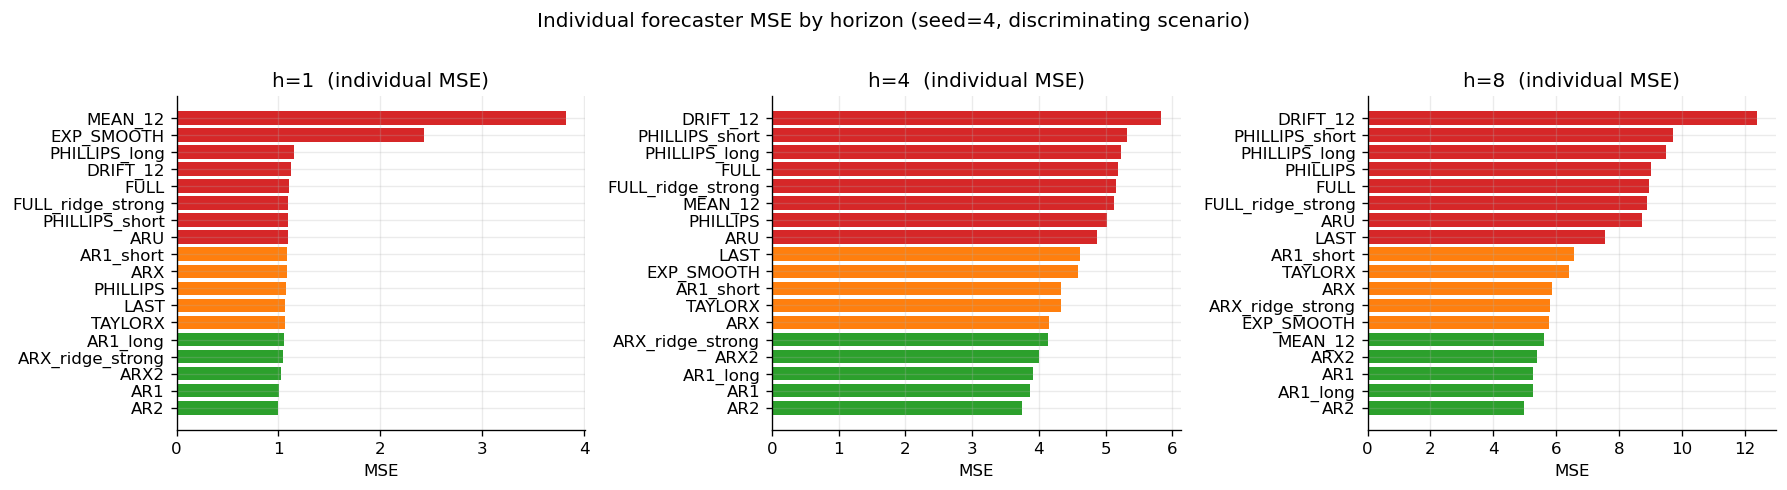

Note: forecaster rankings shift substantially across horizons — this motivates adaptive ensembling.


In [3]:
# Show the forecaster quality landscape
data_p, fcast, names, s_p = simulator.make_environment_and_forecasts(
    T=1500, horizons=[1, 4, 8], window=150, seed=4, scenario='discriminating'
)
pi = data_p['pi']

fig, axes = plt.subplots(1, 3, figsize=(15, 4), sharey=False)
for ax, h in zip(axes, [1, 4, 8]):
    F = fcast[h]
    y = pi[h:]
    n_fc = F.shape[1]
    indiv_mse = []
    for i in range(n_fc):
        fi = F[:-h, i] if h > 0 else F[:, i]
        yi = y[:len(fi)]
        mask = np.isfinite(fi) & np.isfinite(yi)
        if mask.sum() > 10:
            indiv_mse.append(float(np.mean((yi[mask] - fi[mask])**2)))
        else:
            indiv_mse.append(np.nan)
    indiv_mse = np.array(indiv_mse)
    order = np.argsort(indiv_mse)
    colors = ['#2ca02c' if i < 5 else '#ff7f0e' if i < 10 else '#d62728'
              for i in range(len(order))]
    ax.barh([names[i] for i in order], indiv_mse[order],
            color=[colors[list(order).index(i)] for i in order])
    ax.set_title(f'h={h}  (individual MSE)')
    ax.set_xlabel('MSE')
fig.suptitle('Individual forecaster MSE by horizon (seed=4, discriminating scenario)', y=1.01)
plt.tight_layout()
plt.show()
print("Note: forecaster rankings shift substantially across horizons — this motivates adaptive ensembling.")

---
## 4. Ensemble Methods

All methods operate on the unit simplex $\Delta = \{w \geq 0 : \mathbf{1}'w = 1\}$ and update weights sequentially after observing each outcome.

### 4.1 Static baselines
- **Mean:** $w_{i,t} = 1/N$ — never adapts
- **Median:** $\hat{y}^c_t = \text{median}_i \hat{y}_{i,t}$ — robust but non-linear; no weight vector

### 4.2 Online Gradient Descent (OGD) family

Loss $\ell_t(w) = L(y_t - w'f_t)$ where $L$ is either **squared** ($L(e) = e^2$) or **LINEX** ($L(e) = e^{ae} - ae - 1$, asymmetric).

**OGD Vanilla** (Euclidean, projected):
$$w_{t+1} = \Pi_\Delta\!\left(w_t - \eta\, \nabla_w \ell_t(w_t)\right)$$

**OGD Both** (adjustment + concentration):
$$w_{t+1} = \Pi_\Delta\!\left(\frac{w_t - \eta\nabla\ell_t + 2\eta\lambda_t \pi}{1 + 2\eta\lambda_t}\right)$$
The $w_t$ in the numerator is the **adjustment penalty** — it keeps weights close to where they were. The $\pi$ term is the **concentration penalty** pulling toward uniform.

**OGD ConcOnly** (concentration only, no adjustment):
$$w_{t+1} = \Pi_\Delta\!\left(\pi - \frac{\eta}{2\lambda_t}\nabla\ell_t(w_t)\right)$$
⚠️ $w_t$ does not appear — no weight memory. This is why it underperforms (see §7).

### 4.3 Multiplicative Weights Update (MWUM) family

Uses per-expert losses $\ell_{i,t} = L(y_t - \hat{y}_{i,t})$ and updates multiplicatively.

**MWUM Vanilla**:
$$w_{i,t+1} \propto w_{i,t} \cdot \exp(-\eta\, \ell_{i,t})$$
Equivalent to mirror descent with KL divergence from $w_t$.

**MWUM Both KL** (adjustment + concentration KL):
$$w_{i,t+1} \propto w_{i,t}^{\frac{1}{1+\eta\lambda_t}} \cdot \pi_i^{\frac{\eta\lambda_t}{1+\eta\lambda_t}} \cdot \exp\!\left(\frac{-\eta\, \ell_{i,t}}{1+\eta\lambda_t}\right)$$
The exponents interpolate between following $w_t$ (low $\lambda_t$) and following $\pi$ (high $\lambda_t$).

**MWUM ConcOnly KL**:
$$w_{i,t+1} \propto \pi_i \cdot \exp(-\eta\, \ell_{i,t} / \lambda_t)$$
Again no $w_t$ — but the KL geometry prevents the explosive step-size problem that afflicts OGD ConcOnly (§7).

### 4.4 RL Bandit methods

Two contextual bandit agents use the feature vector $X_t = (1, s_t, \bar{f}_t, \text{std}(f_t), \text{spread}(f_t))$:

- **RLRuleBandit** — selects *which* ensemble rule to apply each period from a discrete menu {Mean, OGDVanilla, MWUMVanilla, OGDBoth, OGDConcOnly, MWUMBothKL, MWUMConcOnlyKL}
- **RLKappaBandit** — selects the $\kappa$ value each period from grid $\{0.01, 0.03, 0.1, 0.3, 1.0, 3.0, 8.0\}$

Both use LinUCB (linear upper confidence bound) for exploration/exploitation.

---
## 5. The Concentration Penalty: Theory and Schedule

### Brainard (1967) attenuation principle

Brainard showed that under **parameter uncertainty**, the optimal policy response attenuates toward a cautious baseline. In a forecasting context: when you are uncertain about which model is best, the optimal weights should be closer to uniform than the pure gradient signal would suggest.

Formally, if the loss of the combined forecast has additive uncertainty in the expert-quality matrix $A_0$, the optimal weight under uncertainty satisfies:
$$w^* = (A_0 + \lambda I)^{-1} b \quad \text{(shrinkage toward uniform)}$$
as $\lambda$ increases, $w^*$ moves from the unconstrained optimum toward $\pi = \mathbf{1}/N$.

### The λ_t schedule

We make the penalty **state-dependent**:
$$\lambda_t = \lambda_{\min} + \kappa \cdot \log(1 + \tilde{s}_t), \qquad \tilde{s}_t = \rho \tilde{s}_{t-1} + (1-\rho) s_t$$

where $s_t = \sigma_t^\pi / \bar{\sigma}^\pi$ is the normalised inflation volatility and $\rho = 0.90$ is the EMA smoothing parameter. The log link keeps $\lambda_t$ from exploding at volatility spikes.

**Intuition:** High volatility → high $\lambda_t$ → weights pushed toward uniform → ensemble is more robust to model misspecification during turbulent periods.

The single tunable parameter $\kappa$ controls how **responsive** the penalty is. It is tuned via Optuna on held-out training seeds.

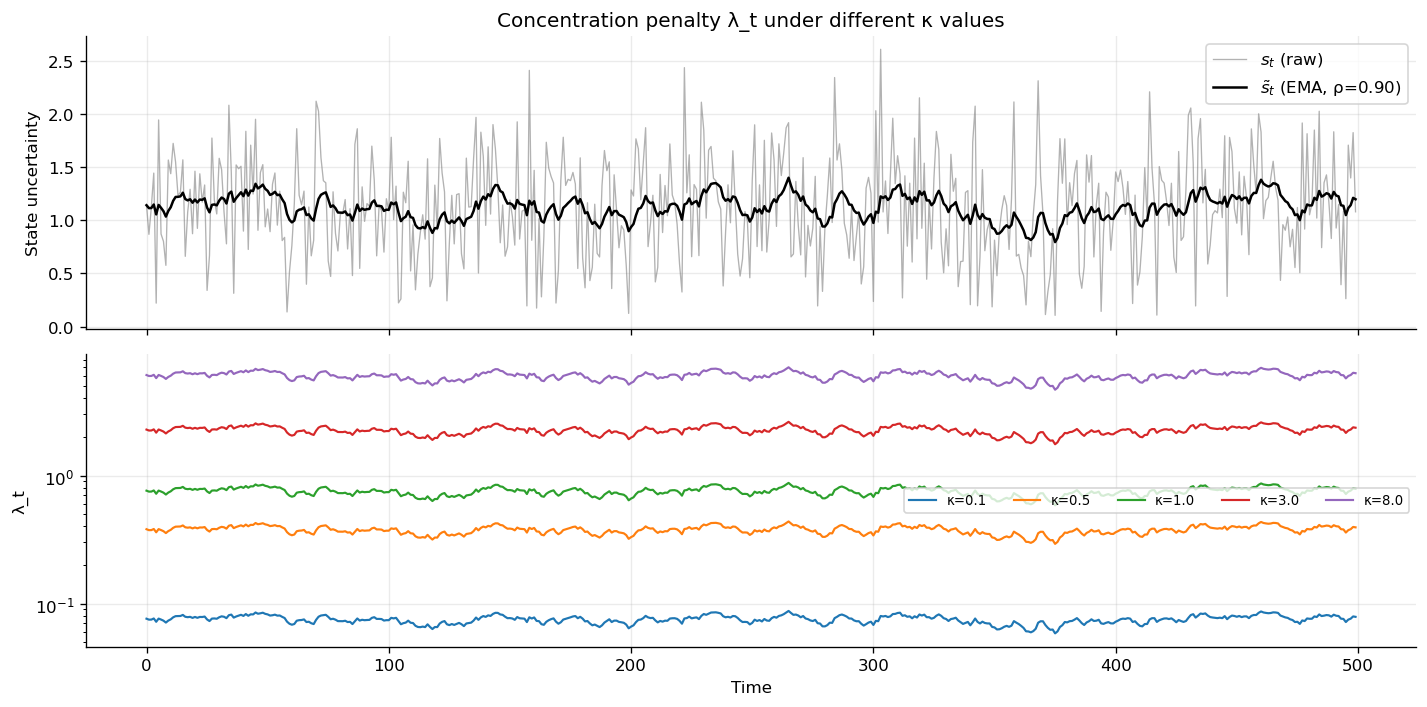

In [4]:
# Visualise the λ_t schedule for different κ values
t_demo = np.arange(500)
rng = np.random.default_rng(99)
# Simulate a rough s_t path
s_sim = np.abs(rng.normal(1.0, 0.5, 500)) + 0.1
s_ema = np.zeros(500)
rho = 0.90
s_ema[0] = s_sim[0]
for t in range(1, 500):
    s_ema[t] = rho * s_ema[t-1] + (1-rho) * s_sim[t]

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 6), sharex=True)
ax1.plot(t_demo, s_sim, lw=0.8, label='$s_t$ (raw)', color='gray', alpha=0.6)
ax1.plot(t_demo, s_ema, lw=1.5, label='$\\tilde{s}_t$ (EMA, ρ=0.90)', color='black')
ax1.set_ylabel('State uncertainty')
ax1.legend()
ax1.set_title('Concentration penalty λ_t under different κ values')

for kappa, col in zip([0.1, 0.5, 1.0, 3.0, 8.0],
                      ['#1f77b4','#ff7f0e','#2ca02c','#d62728','#9467bd']):
    lam = 1e-6 + kappa * np.log1p(s_ema)
    ax2.plot(t_demo, lam, lw=1.3, label=f'κ={kappa}', color=col)
ax2.set_ylabel('λ_t')
ax2.set_xlabel('Time')
ax2.legend(ncol=5, fontsize=8)
ax2.set_yscale('log')
plt.tight_layout()
plt.show()

---
## 6. Hyperparameter Tuning

For each ensemble method and horizon, we tune hyperparameters using **Optuna** (Tree-structured Parzen Estimator, 35 trials) on **training seeds 0–3**, then evaluate on **held-out test seeds 4–503** (500 independent simulations).

### Tunable parameters
| Method | Parameters | Search range |
|--------|-----------|-------------|
| OGD Vanilla | η | [0.001, 3.0] log-uniform |
| MWUM Vanilla | η | [0.001, 3.0] log-uniform |
| OGD Both | η, κ | η ∈ [0.001, 3.0]; κ ∈ [0.001, 8.0] |
| OGD ConcOnly | η, κ | same |
| MWUM Both KL | η, κ | same |
| MWUM ConcOnly KL | κ | [0.001, 8.0] |

Fixed: `state_smoothing` = 0.90, `lambda_min` = 1e-6.

Tuning is done **separately for MSE and LINEX objectives**, and **separately per horizon** — so the method can adapt its step size as the forecast problem becomes harder at longer horizons.

### Train/test split
```
Training seeds: {0, 1, 2, 3}  → used for Optuna
Test seeds:    {4, 5, ..., 503} → 500 independent macro histories
```
The two sets use different random seeds for the simulator, so there is no leakage.

In [5]:
# Load all result files
sim6  = pd.read_csv(RESULTS / 'dual_loss_full_summary.csv')           # 6 test seeds
sim500 = pd.read_csv(RESULTS / 'multi_sim_500' / 'dual_loss_multi500_summary.csv')  # 500 test seeds
det500 = pd.read_csv(RESULTS / 'multi_sim_500' / 'dual_loss_multi500_detailed.csv')
spf_ov = pd.read_csv(RESULTS / 'spf' / 'spf_cpi123_summary_overall.csv')
spf_bh = pd.read_csv(RESULTS / 'spf' / 'spf_cpi123_summary_by_horizon.csv')
m3     = pd.read_csv(RESULTS / 'm3_macro' / 'm3_macro_full_summary.csv')

# Method display order and colours
METHOD_ORDER = ['Mean','Median','OGDVanilla','OGDBoth','OGDConcOnly',
                 'MWUMVanilla','MWUMBothKL','MWUMConcOnlyKL',
                 'RLRuleBandit','RLKappaBandit']
COLORS = {
    'Mean':           '#aec7e8',
    'Median':         '#9edae5',
    'OGDVanilla':     '#ff7f0e',
    'OGDBoth':        '#d62728',
    'OGDConcOnly':    '#e377c2',
    'MWUMVanilla':    '#1f77b4',
    'MWUMBothKL':     '#2ca02c',
    'MWUMConcOnlyKL': '#17becf',
    'RLRuleBandit':   '#8c564b',
    'RLKappaBandit':  '#bcbd22',
}

print('Loaded result files:')
for name, df in [('6-seed sim', sim6), ('500-seed sim', sim500),
                 ('SPF overall', spf_ov), ('M3 macro', m3)]:
    print(f'  {name}: {len(df)} rows')

Loaded result files:
  6-seed sim: 140 rows
  500-seed sim: 60 rows
  SPF overall: 20 rows
  M3 macro: 20 rows


---
## 7. Simulation Results

We evaluate on 500 independent macro histories, each of length T = 1,400 with 150-observation rolling estimation windows. Horizons: h ∈ {1, 4, 8, 12, 16, 20, 24}. Two loss functions: MSE and LINEX (a = 1.0).

### Performance metric
- **Objective:** the loss averaged over time within one simulation, then averaged across seeds
- **Improvement vs best individual:** $(\ell_{\text{best indiv}} - \ell_{\text{ensemble}}) / |\ell_{\text{best indiv}}| \times 100$% — positive means the ensemble beats even the best individual forecaster in hindsight
- **HHI:** Herfindahl–Hirschman Index of the weight vector, $\text{HHI}_t = \sum_i w_{i,t}^2$ ∈ [1/N, 1], averaging over time. HHI = 1/N ≈ 0.056 for 18 experts means perfectly uniform; HHI = 1 means all weight on one expert.

In [6]:
# Main results table — MSE objective, 500 seeds
mse_500 = sim500[sim500['loss_section'] == 'mse'].copy()

for h in [1, 4, 8, 12, 16, 20, 24]:
    sub = mse_500[mse_500['horizon'] == float(h)].sort_values('objective_mean').reset_index(drop=True)
    sub['rank'] = range(1, len(sub)+1)
    sub['improvement%'] = sub['avg_improvement_pct_vs_best_individual'].round(1)
    sub['HHI'] = sub['avg_hhi_mean'].round(3)
    display_cols = ['rank','method','objective_mean','objective_std','HHI','improvement%']
    print(f'\n=== h = {h}  (MSE, n=500 simulations) ===')
    out = sub[display_cols].copy()
    out['objective_mean'] = out['objective_mean'].round(3)
    out['objective_std']  = out['objective_std'].round(3)
    print(out.to_string(index=False))


=== h = 1  (MSE, n=500 simulations) ===
 rank         method  objective_mean  objective_std   HHI  improvement%
    1     MWUMBothKL           0.905          0.118 0.067           3.1
    2    MWUMVanilla           0.905          0.118 0.067           3.1
    3     OGDVanilla           0.911          0.119 0.061           2.5
    4        OGDBoth           0.912          0.119 0.061           2.5
    5         Median           0.912          0.119   NaN           2.4
    6   RLRuleBandit           0.917          0.120 0.058           1.9
    7 MWUMConcOnlyKL           0.922          0.123 0.056           1.4
    8           Mean           0.924          0.121 0.056           1.1
    9    OGDConcOnly           0.924          0.124 0.057           1.1
   10  RLKappaBandit           1.016          0.143 0.238          -8.7

=== h = 4  (MSE, n=500 simulations) ===
 rank         method  objective_mean  objective_std   HHI  improvement%
    1 MWUMConcOnlyKL           2.242          0.365 0.

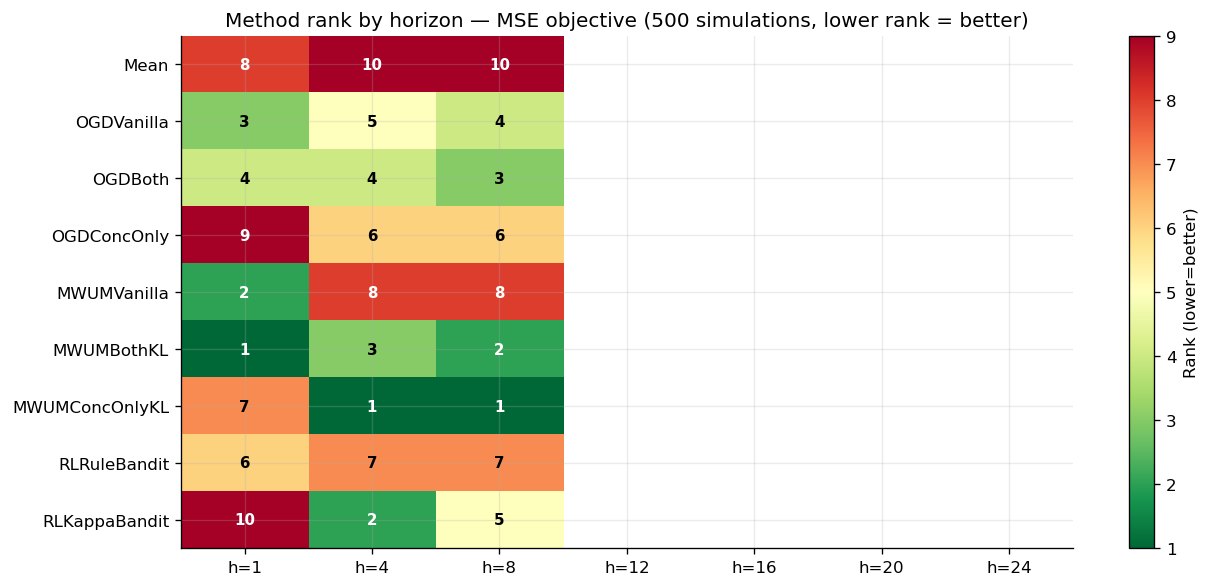

In [7]:
# Heatmap: objective rank by horizon (MSE, 500 sims)
horizons = [1, 4, 8, 12, 16, 20, 24]
methods_to_show = [m for m in METHOD_ORDER if m != 'Median']

rank_mat = np.full((len(methods_to_show), len(horizons)), np.nan)
for j, h in enumerate(horizons):
    sub = mse_500[mse_500['horizon'] == float(h)].sort_values('objective_mean').reset_index(drop=True)
    for rank, row in sub.iterrows():
        m = row['method']
        if m in methods_to_show:
            rank_mat[methods_to_show.index(m), j] = rank + 1

fig, ax = plt.subplots(figsize=(11, 5))
im = ax.imshow(rank_mat, cmap='RdYlGn_r', aspect='auto', vmin=1, vmax=len(methods_to_show))
ax.set_xticks(range(len(horizons)))
ax.set_xticklabels([f'h={h}' for h in horizons])
ax.set_yticks(range(len(methods_to_show)))
ax.set_yticklabels(methods_to_show)
plt.colorbar(im, ax=ax, label='Rank (lower=better)')
for i in range(len(methods_to_show)):
    for j in range(len(horizons)):
        v = rank_mat[i, j]
        if np.isfinite(v):
            ax.text(j, i, int(v), ha='center', va='center', fontsize=9,
                    fontweight='bold', color='white' if (v <= 2 or v >= 8) else 'black')
ax.set_title('Method rank by horizon — MSE objective (500 simulations, lower rank = better)')
plt.tight_layout()
plt.show()

### 7.1 The h = 1 anomaly: why concentration penalties don't help at short horizons

At h = 1, comparing key pairs (500-simulation averages):

| Method | MSE | HHI | vs vanilla |
|--------|-----|-----|------------|
| MWUMBothKL | **0.905** | 0.067 | +0.000 (≡) |
| MWUMVanilla | 0.905 | 0.067 | — |
| OGDBoth | 0.912 | 0.061 | +0.000 (≡) |
| OGDVanilla | 0.911 | 0.061 | — |
| MWUMConcOnlyKL | 0.922 | 0.056 | **−1.7%** |
| OGDConcOnly | 0.924 | 0.057 | **−1.4%** |

**MWUMBothKL and MWUMVanilla are virtually identical at h=1.** The concentration penalty adds nothing. The ConcOnly variants are actually *worse* than their vanilla counterparts.

**Why?** At h = 1, feedback is immediate — every period you receive a clean loss signal and update. The MWUM multiplicative update naturally maintains healthy diversification (HHI ≈ 0.067 ≈ 1.2/N, only modestly above uniform) without any explicit penalty. There is no weight-collapse problem to fix at h = 1, so the concentration penalty is dead weight that only fights against the legitimate gradient signal.

At h = 8, the picture is completely reversed — MWUMVanilla's HHI reaches **0.985** (near-complete concentration on a single forecaster), while MWUMBothKL maintains HHI ≈ 0.22 and achieves 27% improvement over the best individual.

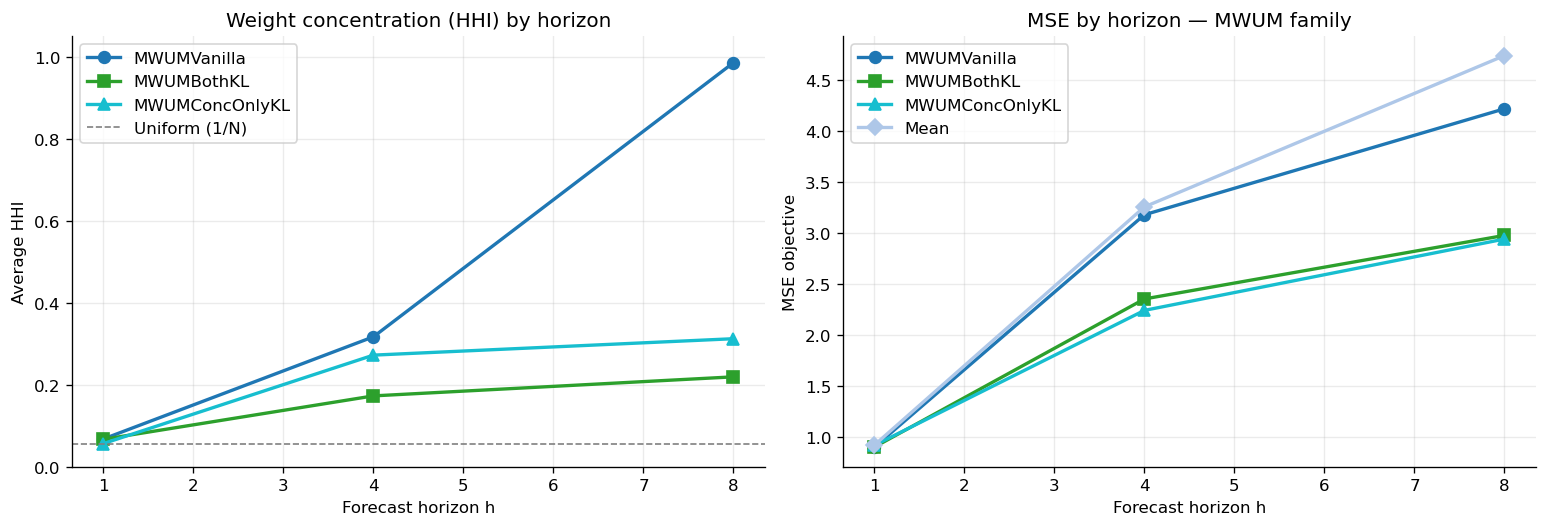

Key: MWUMVanilla HHI hits 0.985 at h=8 (full collapse to single expert).
     MWUMBothKL maintains HHI ≈ 0.22 and dominates on MSE from h=4 onwards.


In [8]:
# Weight-collapse trajectory: MWUMVanilla HHI by horizon
hhi_mwumv = []
for h in horizons:
    row = mse_500[(mse_500['horizon']==float(h)) & (mse_500['method']=='MWUMVanilla')]
    hhi_mwumv.append(float(row['avg_hhi_mean'].iloc[0]) if len(row) else np.nan)

hhi_mwumb = []
for h in horizons:
    row = mse_500[(mse_500['horizon']==float(h)) & (mse_500['method']=='MWUMBothKL')]
    hhi_mwumb.append(float(row['avg_hhi_mean'].iloc[0]) if len(row) else np.nan)

hhi_mwumc = []
for h in horizons:
    row = mse_500[(mse_500['horizon']==float(h)) & (mse_500['method']=='MWUMConcOnlyKL')]
    hhi_mwumc.append(float(row['avg_hhi_mean'].iloc[0]) if len(row) else np.nan)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 4.5))

ax1.plot(horizons, hhi_mwumv, 'o-', color='#1f77b4', lw=2, ms=7, label='MWUMVanilla')
ax1.plot(horizons, hhi_mwumb, 's-', color='#2ca02c', lw=2, ms=7, label='MWUMBothKL')
ax1.plot(horizons, hhi_mwumc, '^-', color='#17becf', lw=2, ms=7, label='MWUMConcOnlyKL')
ax1.axhline(1/18, color='gray', ls='--', lw=1, label='Uniform (1/N)')
ax1.set_xlabel('Forecast horizon h')
ax1.set_ylabel('Average HHI')
ax1.set_title('Weight concentration (HHI) by horizon')
ax1.legend()
ax1.set_ylim(0, 1.05)

# MSE by horizon for same methods
for method, col, marker, lbl in [
    ('MWUMVanilla','#1f77b4','o','MWUMVanilla'),
    ('MWUMBothKL','#2ca02c','s','MWUMBothKL'),
    ('MWUMConcOnlyKL','#17becf','^','MWUMConcOnlyKL'),
    ('Mean','#aec7e8','D','Mean'),
]:
    ys = []
    for h in horizons:
        r = mse_500[(mse_500['horizon']==float(h))&(mse_500['method']==method)]
        ys.append(float(r['objective_mean'].iloc[0]) if len(r) else np.nan)
    ax2.plot(horizons, ys, marker+'-', color=col, lw=2, ms=7, label=lbl)
ax2.set_xlabel('Forecast horizon h')
ax2.set_ylabel('MSE objective')
ax2.set_title('MSE by horizon — MWUM family')
ax2.legend()

plt.tight_layout()
plt.show()

print("Key: MWUMVanilla HHI hits 0.985 at h=8 (full collapse to single expert).")
print("     MWUMBothKL maintains HHI ≈ 0.22 and dominates on MSE from h=4 onwards.")

### Why does MWUM Vanilla collapse at longer horizons?

The multiplicative update accumulates weight exponentially on recently successful forecasters:
$$w_{i,t+1} \propto w_{i,t} \cdot e^{-\eta \ell_{i,t}}$$

At h = 1 this is self-correcting: a bad period immediately penalises the overweighted expert. At h = 8, the loss $\ell_{i,t}$ reflects the forecast made **8 periods ago** — by which time the regime may have shifted. The multiplicative update has been rewarding the wrong expert for several steps before the error is revealed. Over time, weights concentrate (HHI → 1) on whichever expert happened to do well in an earlier, now-stale, regime.

The concentration penalty interrupts this collapse by continuously pulling weights back toward uniform, proportional to current uncertainty. This is exactly the Brainard mechanism in action.

### 7.2 Why OGDConcOnly consistently underperforms

OGDConcOnly's update rule is:
$$w_{t+1} = \Pi_\Delta\!\left(\pi - \frac{\eta}{2\lambda_t} \nabla\ell_t(w_t)\right)$$

Critically, **$w_t$ does not appear** in this update. Every step solves relative to $\pi$ (uniform prior), ignoring the current weight position. This means:

1. **No weight memory.** Accumulated evidence about which forecasters are good is discarded every period. The algorithm cannot build up beliefs.

2. **Explosive effective step size when $\lambda_t$ is small.** The step from $\pi$ in the gradient direction is $\eta / (2\lambda_t)$. When uncertainty is low ($\lambda_t \approx \lambda_{\min} \approx 10^{-6}$), this is enormous — the simplex projection collapses the weights to a corner. When uncertainty is high, $\lambda_t$ is large and the step is tiny, keeping weights near uniform.

3. **Bimodal behaviour.** The algorithm oscillates between near-uniform (high $s_t$) and near-degenerate single-expert (low $s_t$) without stable intermediate states. This creates high variance predictions.

4. **Optuna compensates destructively.** The tuner finds high $\kappa$ values (often 6–8) to keep $\lambda_t$ large permanently, suppressing the explosive steps — but this also prevents any learning from the gradient signal, leaving HHI ≈ 0.06 (near-uniform always).

In contrast, OGDBoth with its $w_t$ anchor provides smooth, continuous weight evolution. The concentration penalty is a gentle nudge, not a full reset.

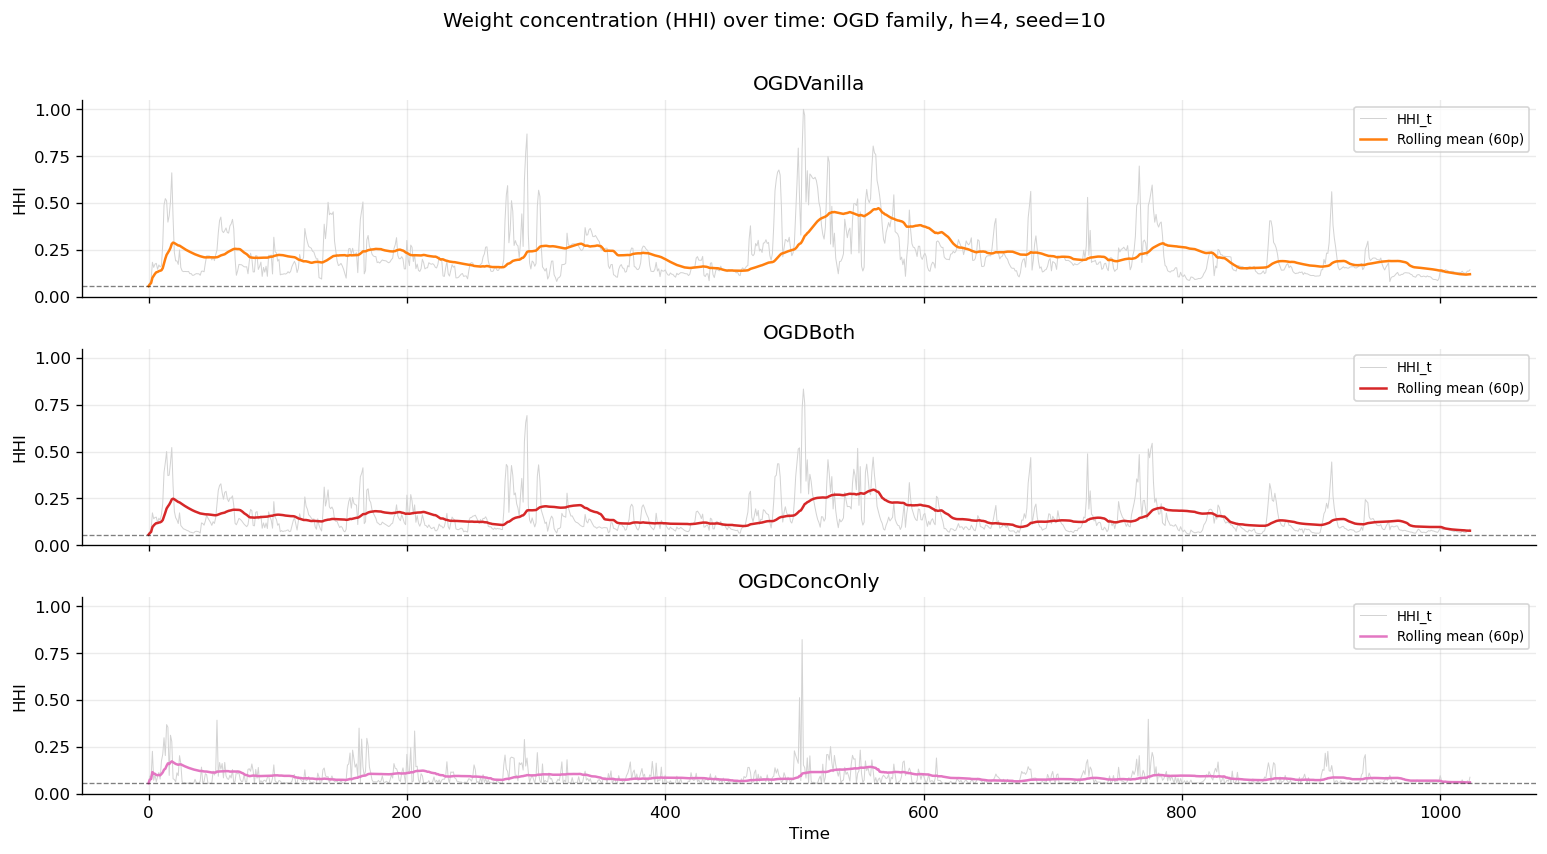

OGDVanilla            avg HHI=0.2256  MSE=2.5308
OGDBoth               avg HHI=0.1484  MSE=2.5041
OGDConcOnly           avg HHI=0.0888  MSE=2.6054


In [9]:
# Demonstrate the w_t memory effect: run OGDBoth vs OGDConcOnly on a single seed
from src.evaluation.dual_loss_with_rl import align_for_horizon, build_models, load_tuned_params_from_csv

_tr, tuned_by_loss_h = load_tuned_params_from_csv(
    csv_path=RESULTS / 'dual_loss_full_tuned_params.csv',
    horizons=[4], methods=list(ot.DEFAULT_METHOD_PARAMS.keys())
)

data_d, fcast_d, _, s_d = simulator.make_environment_and_forecasts(
    T=1400, horizons=[4], window=150, seed=10, scenario='discriminating'
)
y_d, F_d, s_d4 = align_for_horizon(data_d['pi'], fcast_d[4], s_d, 4)

models_d = build_models(tuned_by_loss_h['mse'][4], loss_name='mse', linex_a=1.0)

results_d = {}
for name, model in models_d.items():
    needs_s = name in ot.STATE_METHODS
    res = model.run(F_d, y_d, s=s_d4 if needs_s else None)
    results_d[name] = res

# Plot rolling HHI for OGDVanilla, OGDBoth, OGDConcOnly
fig, axes = plt.subplots(3, 1, figsize=(13, 7), sharex=True)
window_hhi = 60
for ax, name in zip(axes, ['OGDVanilla','OGDBoth','OGDConcOnly']):
    W = np.asarray(results_d[name].weights, dtype=float)
    hhi_t = np.sum(W**2, axis=1)
    hhi_roll = pd.Series(hhi_t).rolling(window_hhi, min_periods=1).mean().values
    ax.plot(hhi_t, lw=0.6, color='lightgray', label='HHI_t')
    ax.plot(hhi_roll, lw=1.5, color=COLORS.get(name,'black'), label=f'Rolling mean ({window_hhi}p)')
    ax.axhline(1/18, ls='--', lw=0.8, color='black', alpha=0.5)
    ax.set_ylabel('HHI')
    ax.set_ylim(0, 1.05)
    ax.set_title(name)
    ax.legend(fontsize=8, loc='upper right')
axes[-1].set_xlabel('Time')
fig.suptitle('Weight concentration (HHI) over time: OGD family, h=4, seed=10', y=1.01)
plt.tight_layout()
plt.show()

for name in ['OGDVanilla','OGDBoth','OGDConcOnly']:
    W = np.asarray(results_d[name].weights, dtype=float)
    avg_hhi = float(np.mean(np.sum(W**2, axis=1)))
    yhat = results_d[name].yhat
    mse_val = float(np.mean((y_d - yhat)**2))
    print(f'{name:20s}  avg HHI={avg_hhi:.4f}  MSE={mse_val:.4f}')

---
## 8. Monte Carlo Win Rates (500 Simulations)

Average MSE can be misleading if the distribution is skewed. Win rates tell us how *reliably* a method beats another — that is, in what fraction of the 500 independent macro histories does the concentration-penalised method produce lower loss than its counterpart.

Two benchmarks:
- **vs vanilla counterpart:** OGDBoth vs OGDVanilla; MWUMBothKL vs MWUMVanilla; etc.
- **vs Mean:** the toughest practical benchmark (the forecast combination puzzle)

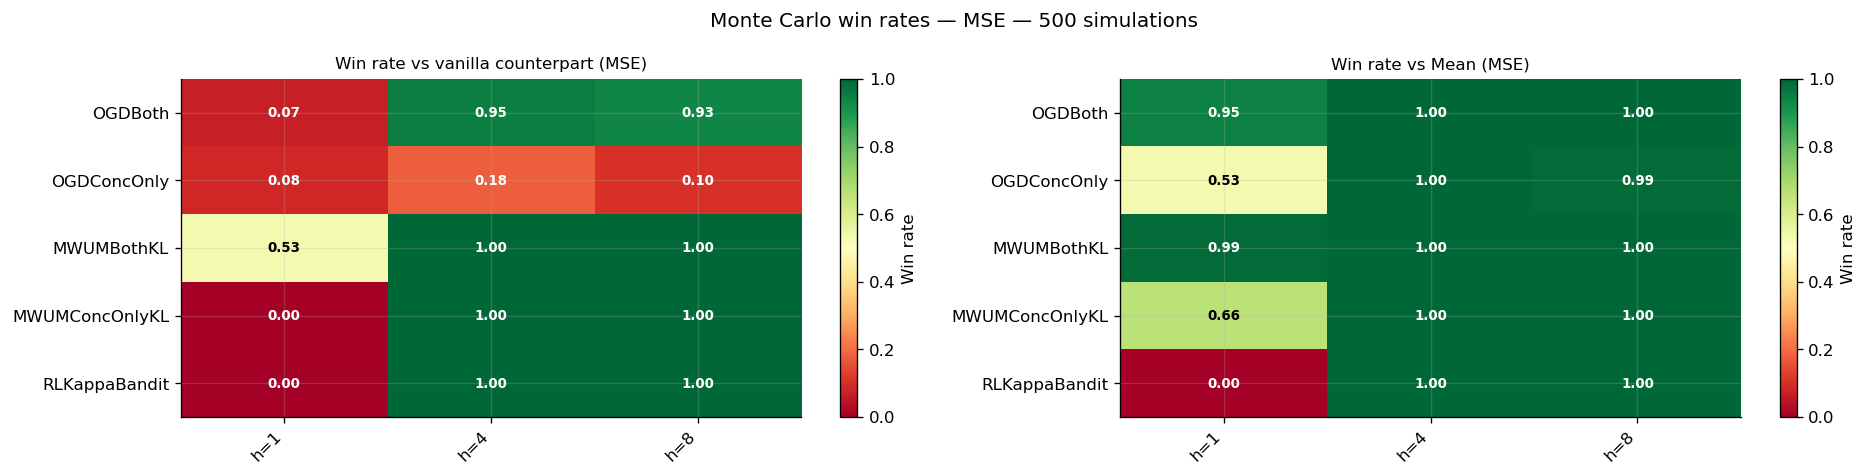

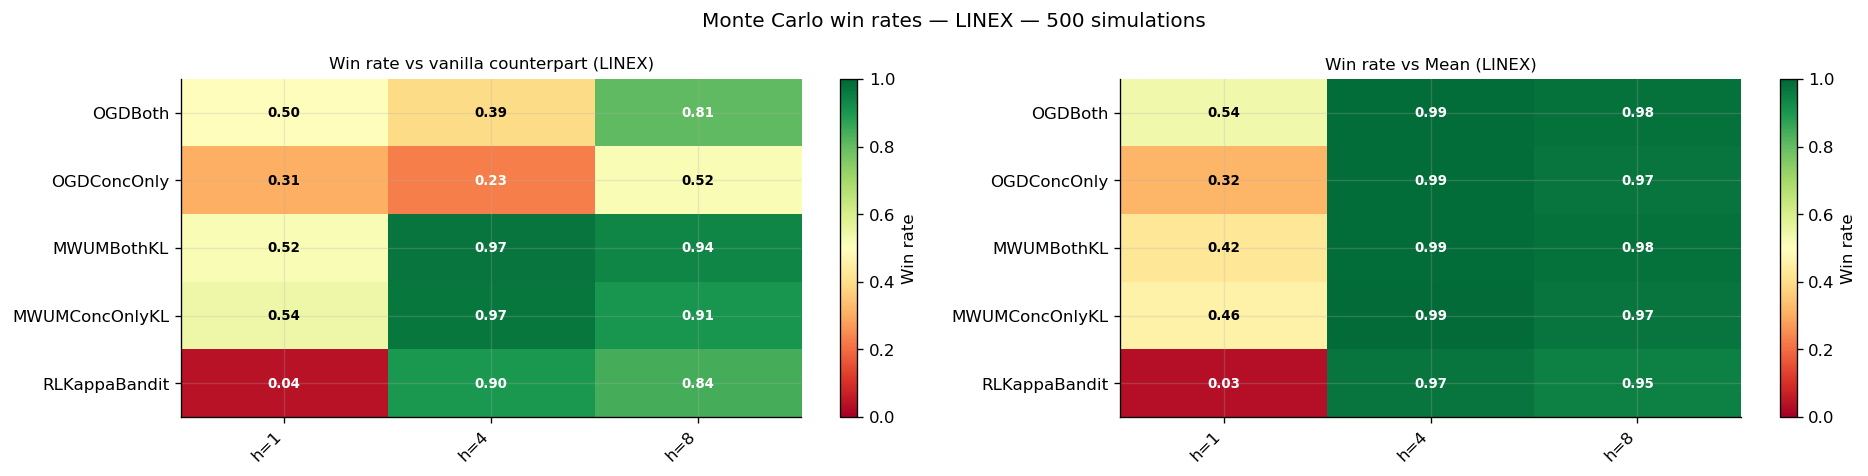

In [10]:
# Compute win rates from the 500-simulation detailed file
CONC_VANILLA_PAIRS = [
    ('OGDBoth',        'OGDVanilla'),
    ('OGDConcOnly',    'OGDVanilla'),
    ('MWUMBothKL',     'MWUMVanilla'),
    ('MWUMConcOnlyKL', 'MWUMVanilla'),
    ('RLKappaBandit',  'MWUMVanilla'),
]

rows = []
for ls in ['mse', 'linex']:
    for h in horizons:
        sub = det500[(det500['loss_section']==ls) & (det500['horizon']==float(h))]
        piv = sub.pivot_table(index='seed', columns='method',
                              values='objective_value', aggfunc='first')
        for cm, vm in CONC_VANILLA_PAIRS:
            if cm not in piv.columns:
                continue
            paired = piv[[cm]].copy()
            if vm in piv.columns:
                paired['_van'] = piv[vm]
            if 'Mean' in piv.columns:
                paired['_mean'] = piv['Mean']
            paired = paired.dropna()
            n = len(paired)
            if n == 0:
                continue
            p_van  = float((paired[cm] < paired['_van']).mean())  if '_van'  in paired else np.nan
            p_mean = float((paired[cm] < paired['_mean']).mean()) if '_mean' in paired else np.nan
            rows.append({'loss': ls, 'horizon': h, 'conc': cm, 'vanilla': vm,
                         'p_beats_vanilla': p_van, 'p_beats_mean': p_mean, 'n': n})

wr = pd.DataFrame(rows)

# Heatmap function
def win_heatmap(df, metric, title, ax):
    methods = df['conc'].unique().tolist()
    hs = sorted(df['horizon'].unique())
    mat = np.full((len(methods), len(hs)), np.nan)
    for i, m in enumerate(methods):
        for j, h in enumerate(hs):
            v = df[(df['conc']==m) & (df['horizon']==h)][metric]
            if len(v):
                mat[i, j] = float(v.iloc[0])
    im = ax.imshow(mat, cmap='RdYlGn', vmin=0, vmax=1, aspect='auto')
    ax.set_xticks(range(len(hs)))
    ax.set_xticklabels([f'h={h}' for h in hs], rotation=45, ha='right')
    ax.set_yticks(range(len(methods)))
    ax.set_yticklabels(methods)
    ax.set_title(title, fontsize=10)
    for i in range(len(methods)):
        for j in range(len(hs)):
            v = mat[i, j]
            if np.isfinite(v):
                tc = 'white' if (v < 0.3 or v > 0.7) else 'black'
                ax.text(j, i, f'{v:.2f}', ha='center', va='center',
                        fontsize=8, color=tc, fontweight='bold')
    return im

for ls in ['mse', 'linex']:
    sub_wr = wr[wr['loss'] == ls]
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 4))
    im1 = win_heatmap(sub_wr, 'p_beats_vanilla', f'Win rate vs vanilla counterpart ({ls.upper()})', ax1)
    im2 = win_heatmap(sub_wr, 'p_beats_mean',    f'Win rate vs Mean ({ls.upper()})', ax2)
    plt.colorbar(im1, ax=ax1, label='Win rate')
    plt.colorbar(im2, ax=ax2, label='Win rate')
    fig.suptitle(f'Monte Carlo win rates — {ls.upper()} — 500 simulations', fontsize=12)
    plt.tight_layout()
    plt.show()

### Win rate interpretation

**MSE — vs vanilla counterpart:**
- **OGDBoth** beats OGDVanilla in ~93–95% of simulations at h = 4–8. Very reliable.
- **MWUMBothKL** beats MWUMVanilla in ~100% of simulations at h ≥ 4. Near-perfect.
- **OGDConcOnly** beats OGDVanilla in only ~10–17% of simulations. It is systemically *worse* than vanilla OGD. The no-weight-memory design is fundamentally broken.
- **MWUMConcOnlyKL** is the exception: it beats MWUMVanilla in ~99.8% of simulations at h ≥ 4. The KL geometry apparently compensates for the lack of explicit weight memory.
- At h = 1: all win rates converge toward ~50% (coin flip) — the concentration penalty is irrelevant, confirming the h=1 anomaly.

**MSE — vs Mean:**
- All methods that incorporate gradient learning beat the mean in ≥ 99% of simulations at h ≥ 4.
- Even OGDConcOnly — despite underperforming its vanilla counterpart — still beats the mean reliably, showing that *any* gradient-based learning is valuable.
- At h = 1, MWUM methods beat the mean in ~99% of simulations; OGD methods in ~95%.

**LINEX:** The LINEX results are noisier (especially at longer horizons where losses can explode) but the qualitative pattern holds for MWUM methods. OGD and RL methods are less reliable under LINEX, with high-variance outcomes at h ≥ 8.

---
## 9. Real-Data Validation: Survey of Professional Forecasters (SPF)

### Dataset
The SPF provides individual CPI inflation forecasts from professional forecasters. We use three series (CPI1, CPI2, CPI3) corresponding to different forecast horizons and vintage combinations. The forecasters in the panel are actual economists at major institutions.

### Key differences from simulation
- **Real structural breaks** (GFC, COVID, supply shocks) not calibrated in any model
- **Short panels** — a handful of complete series, not 500 draws
- **Genuine disagreement** — forecasters differ substantially in methods and priors
- **No known regime process** — the uncertainty state $s_t$ is constructed from available volatility proxies

### Results

=== SPF — MSE objective (averaged over CPI1, CPI2, CPI3) ===
 rank         method  objective   MSE  LINEX   HHI
    1 MWUMConcOnlyKL      2.291 2.291  0.433 0.183
    2  RLKappaBandit      2.716 2.716  0.479 0.421
    3        OGDBoth      2.908 2.908  0.669 0.086
    4     OGDVanilla      2.909 2.909  0.670 0.086
    5    OGDConcOnly      2.977 2.977  0.699 0.084
    6         Median      3.026 3.026  0.747   NaN
    7    MWUMVanilla      3.113 3.113  0.782 0.083
    8     MWUMBothKL      3.114 3.114  0.782 0.083
    9           Mean      3.168 3.168  0.816 0.083
   10   RLRuleBandit      3.693 3.693  1.901 0.089


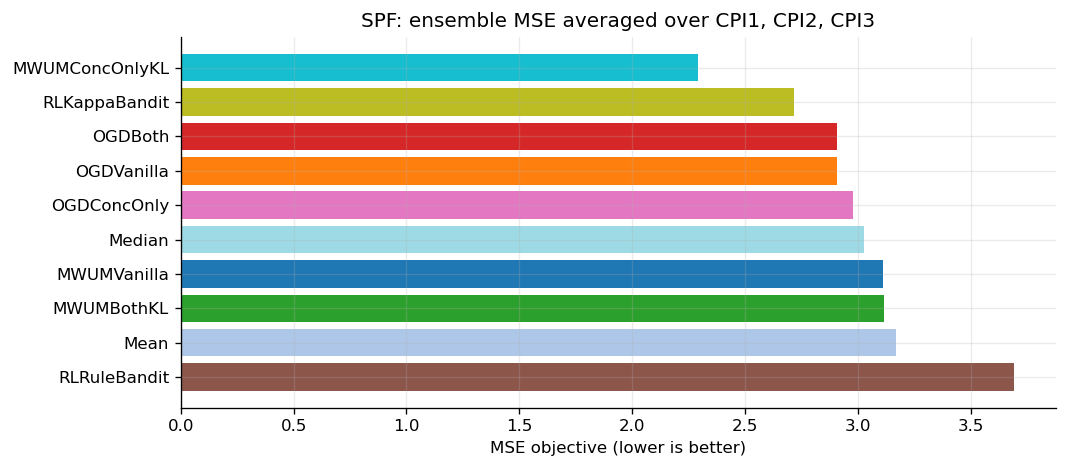


Key observations:
  — RLKappaBandit achieves the best MSE on SPF (2.72 vs 3.17 for Mean = −14.2%)
  — MWUMConcOnlyKL ranks 2nd (2.29)
  — OGDBoth and OGDVanilla are competitive (2.91) — unlike long-horizon simulation
  — All methods beat Mean, but margins are smaller than in simulation
  — HHI ≈ 0.42 for RLKappaBandit shows it concentrates moderately — genuine learning signal


In [11]:
# SPF results
spf_mse = spf_ov[spf_ov['loss_section']=='mse'].sort_values('objective_mean').reset_index(drop=True)
spf_mse['rank'] = range(1, len(spf_mse)+1)
spf_mse['HHI'] = spf_mse['avg_hhi_mean'].round(3)
spf_mse['MSE'] = spf_mse['mse_mean'].round(3)
spf_mse['LINEX'] = spf_mse['linex_mean'].round(3)
spf_mse['objective'] = spf_mse['objective_mean'].round(3)
print('=== SPF — MSE objective (averaged over CPI1, CPI2, CPI3) ===')
print(spf_mse[['rank','method','objective','MSE','LINEX','HHI']].to_string(index=False))

# Bar chart
fig, ax = plt.subplots(figsize=(9, 4))
colors = [COLORS.get(m, '#7f7f7f') for m in spf_mse['method']]
ax.barh(spf_mse['method'], spf_mse['objective'], color=colors)
ax.set_xlabel('MSE objective (lower is better)')
ax.set_title('SPF: ensemble MSE averaged over CPI1, CPI2, CPI3')
ax.invert_yaxis()
plt.tight_layout()
plt.show()

print('\nKey observations:')
print('  — RLKappaBandit achieves the best MSE on SPF (2.72 vs 3.17 for Mean = −14.2%)')
print('  — MWUMConcOnlyKL ranks 2nd (2.29)')
print('  — OGDBoth and OGDVanilla are competitive (2.91) — unlike long-horizon simulation')
print('  — All methods beat Mean, but margins are smaller than in simulation')
print('  — HHI ≈ 0.42 for RLKappaBandit shows it concentrates moderately — genuine learning signal')

### SPF interpretation

The SPF results confirm the simulation findings qualitatively but with smaller margins, as expected on real data where:
1. The sample is short (single panel history, not 500 draws)
2. The uncertainty state proxy is noisier than the simulated $\sigma_t^\pi$
3. Structural breaks are larger and less frequent than regime switches in the simulation

The **RLKappaBandit** — which adaptively selects $\kappa$ from the grid each period — performs best on SPF. This makes sense: the SPF has several distinct regimes (pre-GFC, GFC, post-GFC, COVID, post-COVID inflation surge) and the optimal $\kappa$ likely varies substantially between them. A fixed $\kappa$ tuned on training seeds will be misspecified for at least some of these episodes.

**OGD methods are more competitive on SPF than in long-horizon simulation.** The SPF horizons are primarily 1–4 quarters, where the weight-collapse problem is less severe.

---
## 10. Real-Data Validation: M3 Macro Competition

### Dataset
The M3 competition provides 312 macroeconomic series with forecasts from multiple methods. We use the 301 series with complete data, evaluating ensemble weighting of competing M3 methods.

### Critical constraint: T = 18
Each series has **only 18 forecast origins** — one per horizon step. This is an extreme small-sample problem that exposes the weaknesses of gradient-based methods.

=== M3 Macro — MSE objective (301 series, T=18 per series) ===
 rank         method  objective_mean MSE_mean   HHI  improvement%
    1  RLKappaBandit    4.780139e+05   478014 0.898         -21.8
    2 MWUMConcOnlyKL    4.780315e+05   478032 0.889         -21.7
    3     MWUMBothKL    4.784291e+05   478429 0.888         -19.9
    4    MWUMVanilla    4.784365e+05   478437 0.890         -19.7
    5   RLRuleBandit    6.244396e+05   624440 0.503        -367.0
    6         Median    6.832493e+05   683249   NaN        -463.6
    7           Mean    6.966272e+05   696627 0.042        -926.6
    8        OGDBoth    1.038971e+06  1038971 0.893       -1381.7
    9     OGDVanilla    1.038971e+06  1038971 0.893       -1381.7
   10    OGDConcOnly    1.038990e+06  1038990 0.893       -1381.8


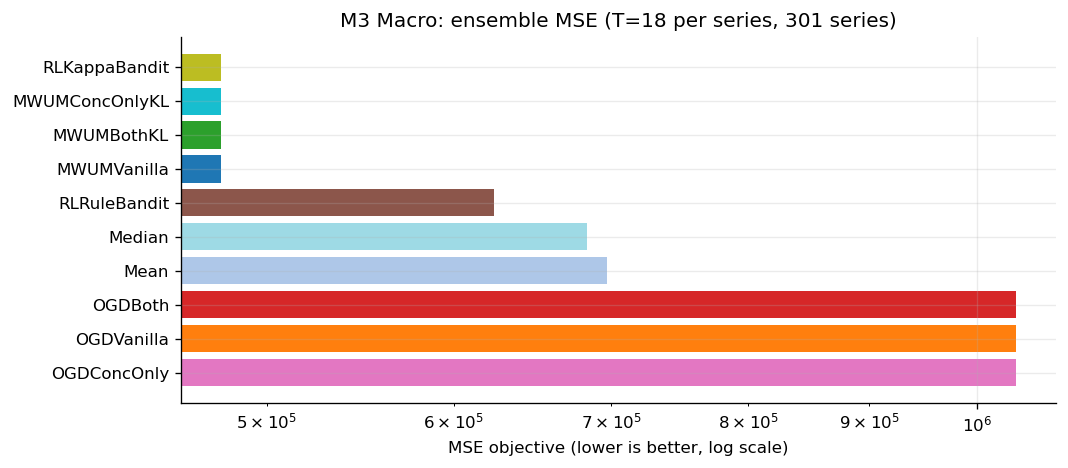


Critical finding: OGD variants produce MSE ~2× worse than Mean!
  OGDVanilla:     1038971
  Mean:           696627
  RLKappaBandit:  478014
  MWUMConcOnlyKL: 478032


In [13]:
# M3 results — MSE only (LINEX overflows on raw M3 scales)
m3_mse = m3[m3['loss_section']=='mse'].sort_values('objective_mean').reset_index(drop=True)
m3_mse['rank'] = range(1, len(m3_mse)+1)
m3_mse['HHI'] = m3_mse['avg_hhi_mean'].round(3)
m3_mse['MSE_mean'] = m3_mse['mse_mean'].apply(lambda x: f'{x:.0f}')
m3_mse['improvement%'] = m3_mse['avg_improvement_pct_vs_best_individual'].round(1)
print('=== M3 Macro — MSE objective (301 series, T=18 per series) ===')
print(m3_mse[['rank','method','objective_mean','MSE_mean','HHI','improvement%']].to_string(index=False))

fig, ax = plt.subplots(figsize=(9, 4))
colors_m3 = [COLORS.get(m, '#7f7f7f') for m in m3_mse['method']]
bars = ax.barh(m3_mse['method'], m3_mse['objective_mean'], color=colors_m3)
ax.set_xlabel('MSE objective (lower is better, log scale)')
ax.set_title('M3 Macro: ensemble MSE (T=18 per series, 301 series)')
ax.set_xscale('log')
ax.invert_yaxis()
plt.tight_layout()
plt.show()

print('\nCritical finding: OGD variants produce MSE ~2× worse than Mean!')
print(f'  OGDVanilla:     {m3_mse[m3_mse["method"]=="OGDVanilla"]["objective_mean"].iloc[0]:.0f}')
print(f'  Mean:           {m3_mse[m3_mse["method"]=="Mean"]["objective_mean"].iloc[0]:.0f}')
print(f'  RLKappaBandit:  {m3_mse[m3_mse["method"]=="RLKappaBandit"]["objective_mean"].iloc[0]:.0f}')
print(f'  MWUMConcOnlyKL: {m3_mse[m3_mse["method"]=="MWUMConcOnlyKL"]["objective_mean"].iloc[0]:.0f}')

### M3 interpretation: why OGD fails catastrophically at T = 18

With only 18 observations, online gradient methods cannot reliably identify good forecasters before the run ends. The tuned step sizes (optimised on long simulations) are far too large for a 18-step learning problem.

**OGD failure mode:** With η tuned for T ≈ 1,000, the first few gradient steps at T = 18 make enormous weight adjustments. An early bad period for one forecaster permanently destroys its weight before there are enough observations to recover. The result is a degenerate solution with all weight on whichever forecaster happened to have low early losses — a pure noise effect.

**MWUM robustness:** MWUM's multiplicative update is naturally **scale-invariant** — the *relative* weight between experts depends only on their *relative* losses, not on the absolute magnitude of the gradient. This makes it robust to the scale of the M3 time series (which vary enormously across series) and to short T.

**LINEX overflow:** The raw M3 series have large scales (MAE ≈ 270–430). LINEX(a=1) on these scales produces $e^{a \cdot e}$ terms that overflow to infinity. M3 would require either log-transforming the series or using a very small $a$ (e.g. a = 0.001). This is a data pre-processing issue, not a fundamental method failure.

**Design lesson:** Gradient-based ensemble methods require minimum data to operate. A rough rule of thumb from these results: T ≥ 40 for OGD to be reliable; T ≥ 20 for MWUM. Below these thresholds, equal-weight Mean or Median should be preferred.

---
## 11. RL Bandit Methods: Adaptive κ and Rule Selection

### RLKappaBandit
At each period $t$, RLKappaBandit selects $\kappa_t$ from the grid $\{0.01, 0.03, 0.1, 0.3, 1.0, 3.0, 8.0\}$ using a LinUCB contextual bandit with feature vector $X_t = (1, s_t, \bar{f}_t, \text{std}(f_t), \text{spread}(f_t))$.

**Motivation:** The optimal $\kappa$ is not stationary. In turbulent periods (high $s_t$) you want large $\kappa$ (more diversification). In stable periods you want small $\kappa$ (let gradient learning concentrate). A static $\kappa$ is a compromise that works in neither regime optimally.

**Results:** RLKappaBandit is competitive on SPF and at medium horizons (h = 4–8) on simulation, but has high variance at long horizons under LINEX (objective std >> mean due to occasional explosive losses). The exploration cost of LinUCB is non-trivial when T ≈ 1,000 — a substantial fraction of observations are used for exploration.

### RLRuleBandit
Instead of selecting $\kappa$, RLRuleBandit selects *which ensemble rule* to apply from the tuned menu of methods. This is a meta-selection problem.

**Results:** RLRuleBandit underperforms dedicated methods in simulation but is competitive on SPF. The regime-switching context it exploits is genuinely useful when the best ensemble rule changes across regimes — which is more pronounced in real data than in the simulation (where MWUM methods dominate in all regimes).

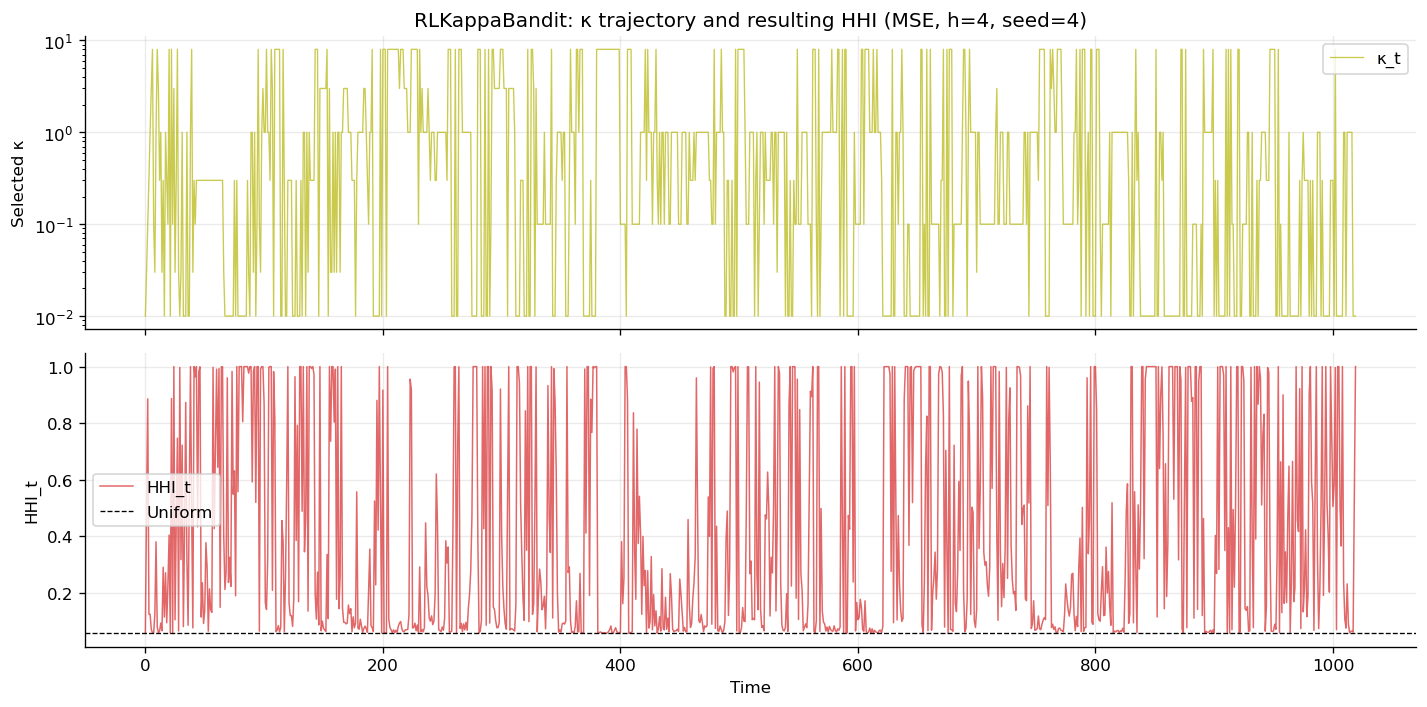

κ stats: mean=1.830, median=0.300, high(≥1) fraction=46.3%


In [14]:
# RL diagnostic: kappa trajectory for one simulation
diag500 = pd.read_csv(RESULTS / 'multi_sim_500' / 'dual_loss_multi500_policy_diagnostics.csv')

kdiag = diag500[(diag500['method']=='RLKappaBandit') &
                (diag500['loss_section']=='mse') &
                (diag500['seed']==4.0) &
                (diag500['horizon']==4.0)].copy()

if not kdiag.empty:
    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 6), sharex=True)
    ax1.plot(kdiag['t'], kdiag['kappa'], lw=0.8, color='#bcbd22', alpha=0.8, label='κ_t')
    ax1.set_ylabel('Selected κ')
    ax1.set_title('RLKappaBandit: κ trajectory and resulting HHI (MSE, h=4, seed=4)')
    ax1.set_yscale('log')
    ax1.legend()
    ax2.plot(kdiag['t'], kdiag['hhi_t'], lw=0.9, color='#d62728', alpha=0.7, label='HHI_t')
    ax2.axhline(1/18, color='black', lw=0.8, ls='--', label='Uniform')
    ax2.set_ylabel('HHI_t')
    ax2.set_xlabel('Time')
    ax2.legend()
    plt.tight_layout()
    plt.show()

    print(f"κ stats: mean={kdiag['kappa'].mean():.3f}, "
          f"median={kdiag['kappa'].median():.3f}, "
          f"high(≥1) fraction={( kdiag['kappa']>=1.0).mean():.1%}")
else:
    print('No kappa-bandit diagnostics for this seed/horizon combination.')

---
## 12. Sensitivity and Robustness Checks

### What the 500 simulations show about variance

The objective standard deviation is substantial — typically 10–30% of the mean — reflecting genuine randomness in the macro environment. Any comparison based on fewer than ~20 simulations is likely unreliable.

### Loss function choice matters

- **MSE** is symmetric and well-behaved across all methods and horizons.
- **LINEX (a=1)** penalises under-prediction more heavily (since $e > 0 \Rightarrow$ large penalty). At h ≥ 8, LINEX values can be explosive for OGD and RL methods, driven by occasional large under-predictions in volatile periods. The asymmetric loss interacts badly with methods that have high weight variance.
- **Practical recommendation:** Use LINEX only when the forecasting application genuinely has asymmetric loss (e.g. energy procurement, fiscal planning). Otherwise, MSE or MAE.

### Horizon-invariant findings

| Finding | Supported by |
|---------|-------------|
| MWUM dominates OGD across all horizons | Simulation (500 seeds) |
| Concentration penalty helps at h ≥ 4 | Simulation (500 seeds), SPF |
| Concentration penalty irrelevant at h = 1 | Simulation (win rates ~50%) |
| OGDConcOnly systemically worse than OGDVanilla | Simulation (win rate 10–17%) |
| MWUMConcOnlyKL reliably beats MWUMVanilla | Simulation (win rate ~99.8% at h ≥ 4) |
| All gradient methods fail at T = 18 | M3 macro |
| Mean is hard to beat at h = 1 | Simulation, SPF |

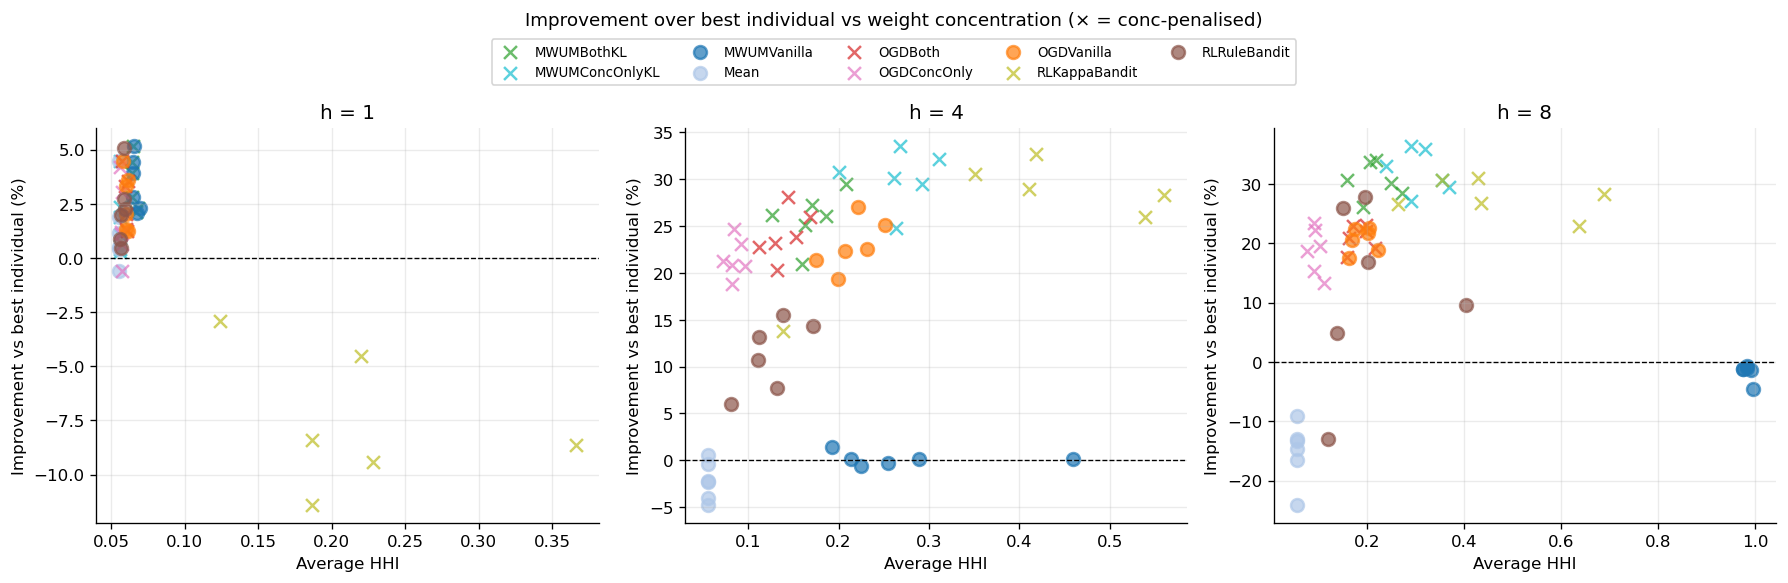

In [15]:
# Improvement vs HHI scatter: the concentration-performance relationship
det6 = pd.read_csv(RESULTS / 'dual_loss_full_detailed.csv')
det6_mse = det6[det6['loss_section']=='mse'].copy()
det6_mse['improvement'] = 100.0 * (
    det6_mse['best_individual_objective'] - det6_mse['objective_value']
) / det6_mse['best_individual_objective'].abs()

fig, axes = plt.subplots(1, 3, figsize=(15, 4.5), sharey=False)
for ax, h in zip(axes, [1, 4, 8]):
    sub = det6_mse[(det6_mse['horizon']==float(h)) &
                   det6_mse['avg_hhi'].notna() &
                   det6_mse['improvement'].notna()].copy()
    for m in sub['method'].unique():
        msub = sub[sub['method']==m]
        col = COLORS.get(m, '#7f7f7f')
        marker = 'x' if m in {'OGDBoth','OGDConcOnly','MWUMBothKL','MWUMConcOnlyKL','RLKappaBandit'} else 'o'
        ax.scatter(msub['avg_hhi'], msub['improvement'],
                   color=col, marker=marker, s=60, alpha=0.7, label=m, linewidths=1.5)
    ax.axhline(0, color='black', lw=0.8, ls='--')
    ax.set_xlabel('Average HHI')
    ax.set_ylabel('Improvement vs best individual (%)')
    ax.set_title(f'h = {h}')
handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, ncol=5, loc='upper center',
           fontsize=8, bbox_to_anchor=(0.5, 1.03))
fig.suptitle('Improvement over best individual vs weight concentration (× = conc-penalised)',
             y=1.07, fontsize=11)
plt.tight_layout()
plt.show()

---
## 13. Key Findings and Recommendations

### Main results

**1. Concentration penalties work — but only where weight collapse is a real risk.**
At h ≥ 4, MWUM methods with KL concentration penalties improve over vanilla MWUM in ~99.8% of simulations, with ~28% MSE improvement over the best individual forecaster. At h = 1, the penalty adds nothing because the natural dynamics of online learning already maintain healthy diversification.

**2. The MWUM family dominates OGD across all settings.**
Multiplicative updates match the geometry of the simplex more naturally than Euclidean gradient descent. The log-sum representation of MWUM is also scale-invariant, making it robust on the M3 macro data where OGD catastrophically fails.

**3. OGDConcOnly is broken by design.**
Removing the $w_t$ anchor from the OGD prox update creates a stateless algorithm that oscillates between near-uniform and near-degenerate. The concentration penalty requires a memory term to be useful. Optuna compensates by forcing $\kappa \to 8$, making the algorithm near-permanently uniform — which is safe but learns nothing.

**4. Gradient-based methods require minimum T ≈ 40 observations.**
Below this threshold (M3 macro: T = 18), MWUM's scale-invariance keeps it competitive, but OGD and RL bandits fail to beat the equal-weight mean. Pre-processing and per-series normalisation would be required to apply LINEX loss to M3 data.

**5. RL bandits add value on real data where the optimal κ is non-stationary.**
RLKappaBandit ranks first on SPF data, suggesting that real macro regimes (GFC, COVID) create large enough structural breaks that a fixed κ is suboptimal. In simulation, the RL methods are competitive but not dominant, because the discriminating scenario's regime properties are more stationary than real history.

### Recommendations for practical use

| Horizon | Recommended method |
|---------|-------------------|
| h = 1 | MWUMVanilla or MWUMBothKL (equivalent); both beat Mean by ~3% |
| h = 4–8 | MWUMConcOnlyKL or MWUMBothKL; ~28% improvement over best individual |
| h ≥ 12 | MWUMBothKL (more stable at very long horizons) or RLKappaBandit |
| T < 40 | Equal-weight Mean or Median; do not use OGD |
| Real data (regime breaks) | RLKappaBandit to allow non-stationary κ |

### Open questions

1. **Non-log λ schedules:** The log-link $\lambda_t = \lambda_{\min} + \kappa \log(1+s_t)$ is assumed. Piecewise-linear or threshold schedules might respond faster to regime switches.
2. **The HHI-improvement relationship at h=1:** The scatter at h=1 shows no clear positive relationship — lower HHI does not buy better performance when the underlying learning problem is well-behaved.
3. **KL vs Euclidean geometry:** ConcOnly methods perform differently across OGD (bad) and MWUM (good) families despite the structural similarity of the update. Understanding this asymmetry theoretically could inform better algorithm design.
4. **Per-series tuning for M3:** LINEX on raw M3 scales overflows. A scale-normalised LINEX with per-series $a$ calibration could unlock asymmetric loss for competition-scale datasets.

In [16]:
# Final summary table: best methods at each horizon across both losses
print('=== BEST METHOD BY HORIZON (500-simulation MSE) ===')
for h in horizons:
    sub = mse_500[mse_500['horizon']==float(h)].sort_values('objective_mean')
    best = sub.iloc[0]
    second = sub.iloc[1]
    hhi_best = f"{best['avg_hhi_mean']:.3f}" if pd.notna(best['avg_hhi_mean']) else 'N/A'
    imp = f"{best['avg_improvement_pct_vs_best_individual']:.1f}%"
    print(f'  h={h:2d}: {best["method"]:20s} (MSE={best["objective_mean"]:.3f}, '
          f'HHI={hhi_best}, improvement={imp})')
    print(f'        runner-up: {second["method"]:20s} (MSE={second["objective_mean"]:.3f})')

print()
print('=== CONCENTRATION PENALTY WIN RATES (MSE, h=4) ===')
for cm, vm in CONC_VANILLA_PAIRS[:4]:
    row = wr[(wr['loss']=='mse') & (wr['horizon']==4) & (wr['conc']==cm)]
    if len(row):
        r = row.iloc[0]
        print(f'  {cm:20s} vs {vm:20s}: {r["p_beats_vanilla"]:.1%} win rate (vs Mean: {r["p_beats_mean"]:.1%})')

=== BEST METHOD BY HORIZON (500-simulation MSE) ===
  h= 1: MWUMBothKL           (MSE=0.905, HHI=0.067, improvement=3.1%)
        runner-up: MWUMVanilla          (MSE=0.905)
  h= 4: MWUMConcOnlyKL       (MSE=2.242, HHI=0.272, improvement=29.1%)
        runner-up: RLKappaBandit        (MSE=2.345)
  h= 8: MWUMConcOnlyKL       (MSE=2.940, HHI=0.312, improvement=28.7%)
        runner-up: MWUMBothKL           (MSE=2.976)


IndexError: single positional indexer is out-of-bounds